<a href="https://colab.research.google.com/github/sujitx-vs/Deep-Neural-Networks---PGCP_AI/blob/main/DDN_Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.data import Dataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Loading Data

In [ ]:
iris = load_iris()
X = iris.data
Y = iris.target

In [ ]:
x = pd.DataFrame(X)

print(x.info())
print()
y = pd.DataFrame(Y)
print(y.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


## Scaling

In [ ]:
scalar = StandardScaler()
X = scalar.fit_transform(X)

##  Training & Testing Split

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

### Sequential Keras Model
- A Keras Sequential model is a linear stack of neural network layers. It is the simplest way to build a deep learning model, where data flows in a strict, one-way sequence—entering the first layer, passing through each hidden layer one by one, and exiting through the final output layer.

In [ ]:
model = keras.Sequential([
    layers.Dense(16,activation='relu',input_shape=(4,)),
    layers.Dense(8,activation='relu'),
    layers.Dense(6,activation='relu'),
    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- input layer is the one defined with input_shape 4
- first Layer with 8 neurons is the hidden layer
- second one with 6 neurons is the hidden layer
- third one with 3 neurons is the output layer
- > this is a basic simple sequential model.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

- > model.summary
- shows the blueprint of the whole model.

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train,Y_train,epochs=50,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2188 - loss: 1.1255 - val_accuracy: 0.4167 - val_loss: 1.0663
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2500 - loss: 1.1007 - val_accuracy: 0.4167 - val_loss: 1.0348
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3542 - loss: 1.0761 - val_accuracy: 0.5000 - val_loss: 1.0051
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4583 - loss: 1.0525 - val_accuracy: 0.5417 - val_loss: 0.9781
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5104 - loss: 1.0310 - val_accuracy: 0.5833 - val_loss: 0.9516
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5625 - loss: 1.0080 - val_accuracy: 0.5833 - val_loss: 0.9288
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5729 - loss: 0.9868 - val_accuracy: 0.6667 - val_loss: 0.9058
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5938 - loss: 0.9659 - val_accuracy: 0.7083 - val_loss: 0.8817


- > Compile
- Used Adam Optimizer - to adjust the weight after each epoch.
- Sparse Categorical CrossEntropy as the loss function - to measure how wrong the model predicting.
- Accuracy is used as the Matrix , that used to show after each epoch

- > Fit

- epoch - No of time model goes one complete pass through your entire dataset.

- batch_size - divided whole data into smaller chunks. Smaller chunks make learning faster and use less computer memory.

- validation_split -  Percent of data that of training data that is uesd to tests the model.

- verbose - tells Python to print out a live progress bar and stats on screen for every single epoch

## Model evaluvation

In [ ]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9000 - loss: 0.3409
Test accuracy: 0.8999999761581421
Test loss: 0.34085026383399963


## Plotting the Results

/tmp/ipykernel_9333/2988003575.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Validation')


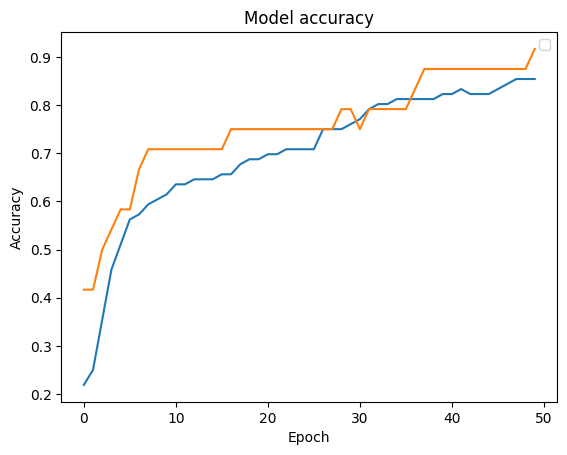

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend('Train', 'Validation')

#Diabetes

- New Dataset.

In [ ]:
df = pd.read_excel('diabetes.xlsx')
df.head()

,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,DietType,Outcome
0,148,72,33.6,0.63,50,1,1
1,85,66,26.6,0.35,31,2,0
2,183,64,23.3,0.67,32,1,1
3,89,66,28.1,0.17,21,1,0
4,137,40,43.1,2.29,33,1,1


In [ ]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [ ]:
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2994 - loss: 0.7874 - val_accuracy: 0.3252 - val_loss: 0.7523
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3605 - loss: 0.7383 - val_accuracy: 0.3984 - val_loss: 0.7170
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4949 - loss: 0.7015 - val_accuracy: 0.5447 - val_loss: 0.6928
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6090 - loss: 0.6744 - val_accuracy: 0.5935 - val_loss: 0.6716
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6619 - loss: 0.6486 - val_accuracy: 0.6098 - val_loss: 0.6523
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.6225 - val_accuracy: 0.6098 - val_loss: 0.6312
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.5955 - val_accuracy: 0.6098 - val_loss: 0.6101
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6640 - loss: 0.5706 - val_accuracy: 0.6098 - 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8766 - loss: 0.3773 
Test accuracy: 0.8766233921051025
Test loss: 0.3772916793823242


/tmp/ipykernel_9333/2988003575.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Train', 'Validation')


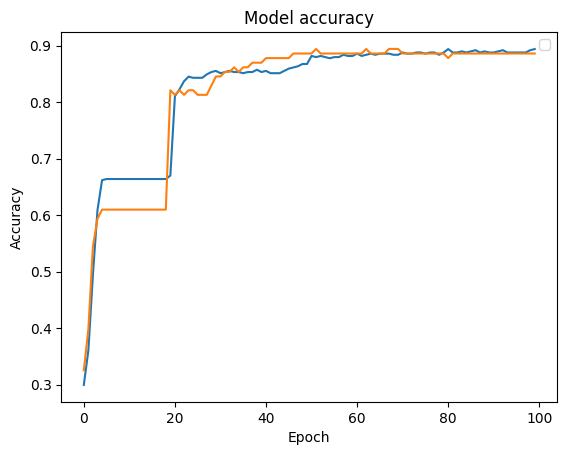

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend('Train', 'Validation')

# Titianic

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

In [ ]:
import seaborn as sns
df = sns.load_dataset('titanic')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[features]
y = df['survived']

## Pipelining is used here.

In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

Numerical and Categorical pipelines.

In [ ]:
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

numerical and categorical features divided.

In [ ]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [ ]:
base_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
base_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_baseline = base_model.fit(X_train, y_train,validation_split=0.2, epochs=50,batch_size=32,verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6942 - loss: 0.6165 - val_accuracy: 0.7273 - val_loss: 0.5870
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7610 - loss: 0.5577 - val_accuracy: 0.7692 - val_loss: 0.5343
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7961 - loss: 0.5111 - val_accuracy: 0.7832 - val_loss: 0.4950
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7926 - loss: 0.4788 - val_accuracy: 0.7972 - val_loss: 0.4684
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7961 - loss: 0.4576 - val_accuracy: 0.8042 - val_loss: 0.4551
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7996 - loss: 0.4427 - val_accuracy: 0.8042 - val_loss: 0.4469
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7979 - loss: 0.4326 - val_accuracy: 0.8112 - val_loss: 0.4432
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7926 - loss: 0.4250 - val_accuracy: 0.8322 - val

In [ ]:
base_loss, base_acc = base_model.evaluate(X_test, y_test)

print("Base model Accuracy:", base_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8045 - loss: 0.4497 
Base model Accuracy: 0.8044692873954773


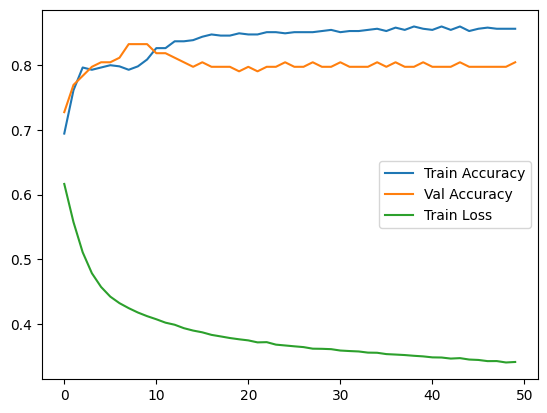

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.legend()
plt.show()

## Model Comparison

In [ ]:
def create_model(optimizer):

    model = keras.Sequential([
        layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
small_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.0001)
)

history_small_lr = small_lr_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.2496 - loss: 0.7935 - val_accuracy: 0.3497 - val_loss: 0.7662
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2654 - loss: 0.7785 - val_accuracy: 0.3776 - val_loss: 0.7538
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3181 - loss: 0.7652 - val_accuracy: 0.4056 - val_loss: 0.7415
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3497 - loss: 0.7519 - val_accuracy: 0.4126 - val_loss: 0.7300
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3620 - loss: 0.7396 - val_accuracy: 0.4336 - val_loss: 0.7192
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3937 - loss: 0.7282 - val_accuracy: 0.4615 - val_loss: 0.7089
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4130 - loss: 0.7172 - val_accuracy: 0.4895 - val_loss: 0.6994
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4605 - loss: 0.7073 - val_accuracy: 0.5175 - v

In [ ]:
medium_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.001)
)
history_medium_lr = medium_lr_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

In [ ]:
large_lr_model = create_model(
    keras.optimizers.Adam(learning_rate=0.01)
)
history_large_lr = large_lr_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

In [ ]:
# Evaluate models on the test set
loss_small_lr, acc_small_lr = small_lr_model.evaluate(X_test, y_test, verbose=0)
loss_medium_lr, acc_medium_lr = medium_lr_model.evaluate(X_test, y_test, verbose=0)
loss_large_lr, acc_large_lr = large_lr_model.evaluate(X_test, y_test, verbose=0)

print("Small LR Model Test Accuracy:",round(acc_small_lr,4))
print("Medium LR Model Test Accuracy:",round(acc_medium_lr,4))
print("Large LR Model Test Accuracy:",round(acc_large_lr,4))

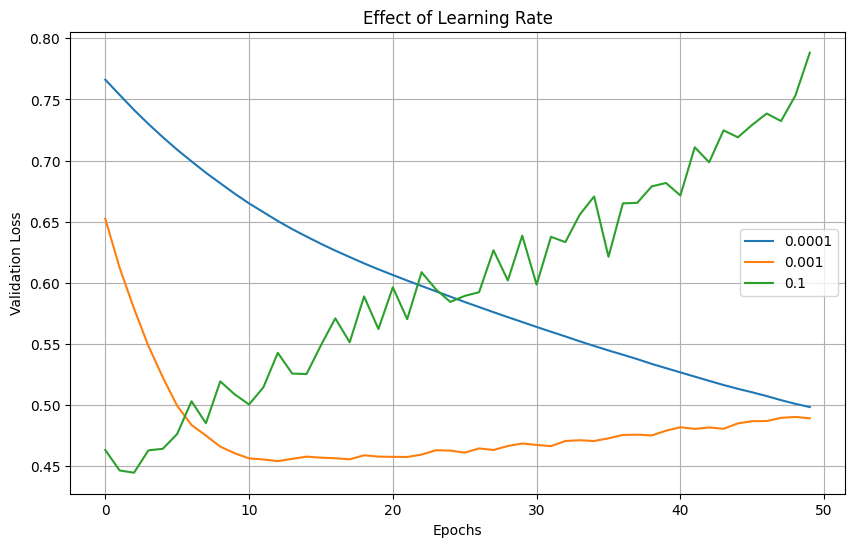

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    history_small_lr.history['val_loss'],
    label='0.0001'
)
plt.plot(
    history_medium_lr.history['val_loss'],
    label='0.001'
)
plt.plot(
    history_large_lr.history['val_loss'],
    label='0.1'
)

plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True)

plt.show()

### Plotting Training History for All Models

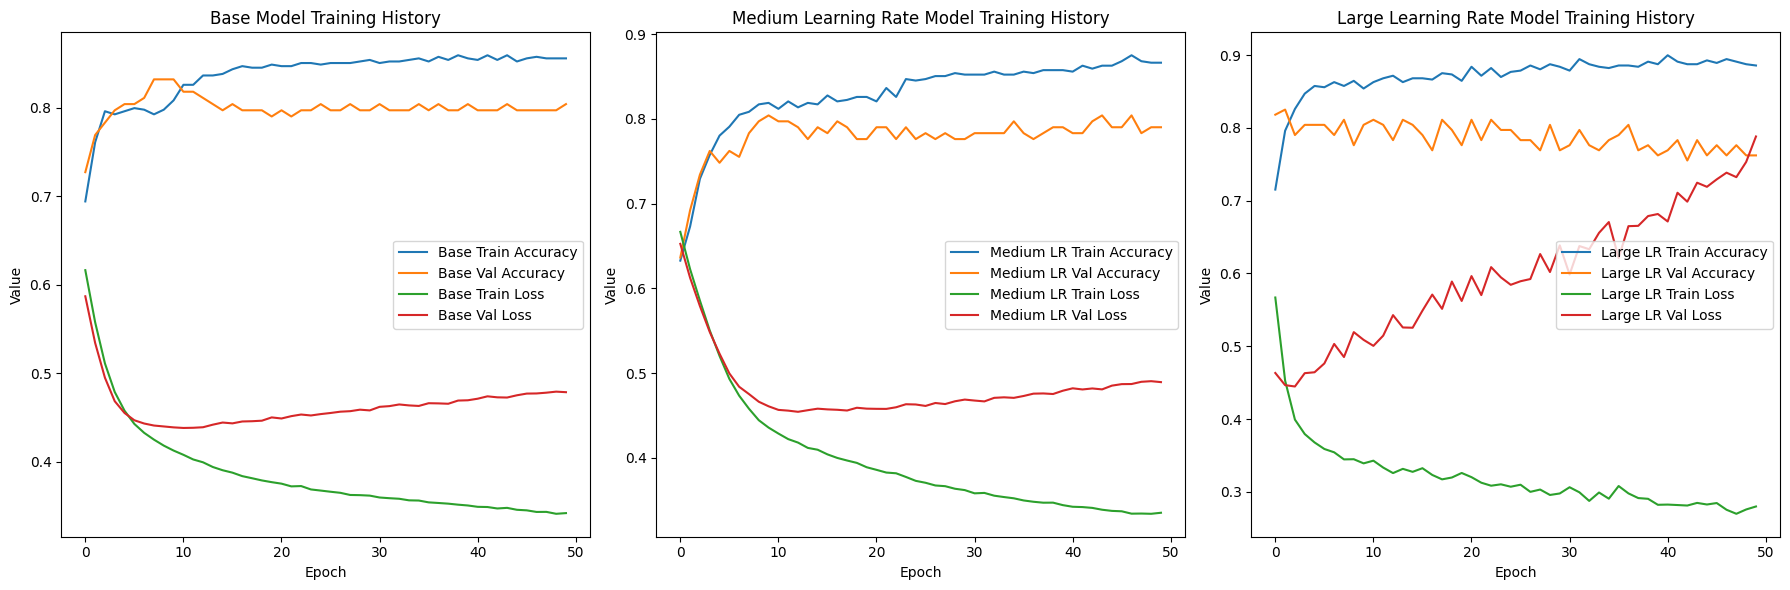

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(history_baseline.history['accuracy'], label='Base Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Base Val Accuracy')
plt.plot(history_baseline.history['loss'], label='Base Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Base Val Loss')
plt.title('Base Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_medium_lr.history['accuracy'], label='Medium LR Train Accuracy')
plt.plot(history_medium_lr.history['val_accuracy'], label='Medium LR Val Accuracy')
plt.plot(history_medium_lr.history['loss'], label='Medium LR Train Loss')
plt.plot(history_medium_lr.history['val_loss'], label='Medium LR Val Loss')
plt.title('Medium Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_large_lr.history['accuracy'], label='Large LR Train Accuracy')
plt.plot(history_large_lr.history['val_accuracy'], label='Large LR Val Accuracy')
plt.plot(history_large_lr.history['loss'], label='Large LR Train Loss')
plt.plot(history_large_lr.history['val_loss'], label='Large LR Val Loss')
plt.title('Large Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

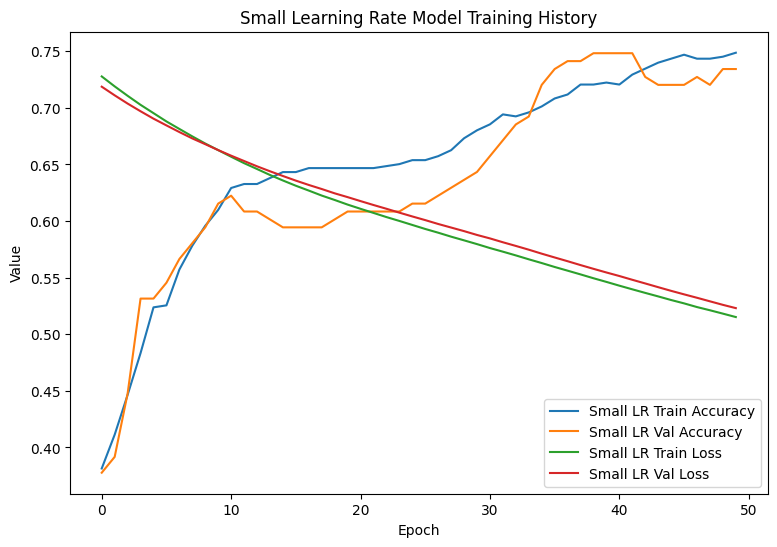

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(history_small_lr.history['accuracy'], label='Small LR Train Accuracy')
plt.plot(history_small_lr.history['val_accuracy'], label='Small LR Val Accuracy')
plt.plot(history_small_lr.history['loss'], label='Small LR Train Loss')
plt.plot(history_small_lr.history['val_loss'], label='Small LR Val Loss')
plt.title('Small Learning Rate Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
# plt.tight_layout()
plt.show()

##Dropout model

In [ ]:
drop_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
drop_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_dropout = drop_model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5395 - loss: 0.7124 - val_accuracy: 0.6643 - val_loss: 0.6497
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6731 - loss: 0.6390 - val_accuracy: 0.7273 - val_loss: 0.6114
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7223 - loss: 0.5899 - val_accuracy: 0.7413 - val_loss: 0.5743
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7399 - loss: 0.5611 - val_accuracy: 0.7762 - val_loss: 0.5420
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7592 - loss: 0.5384 - val_accuracy: 0.7413 - val_loss: 0.5118
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7891 - loss: 0.5095 - val_accuracy: 0.7622 - val_loss: 0.4910
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7663 - loss: 0.4847 - val_accuracy: 0.7762 - val_loss: 0.4787
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7961 - loss: 0.4714 - val_accuracy: 0.7762 - val_loss

In [ ]:
drop_accuracy,drop_loss = drop_model.evaluate(X_test, y_test)
print(f"Dropout Model Accuracy: {drop_accuracy}")
print(f"Dropout Model Loss: {drop_loss}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7877 - loss: 0.4458 
Dropout Model Accuracy: 0.4458300769329071
Dropout Model Loss: 0.7877094745635986


If performance of model is low :


1. Early Stoping
2. Dropout Method
3. L1,L2 Regularlization

Learned about creating sequrntial models using keras.sequrntial, used different datasets on the models and compared different models based on different learning rates and plotted different graphs of these models.